# Causal Set Simulator - Project Overview

This notebook introduces the project and runs a small, end-to-end example.
We keep parameters small so it runs quickly in a notebook.

## Setup
We add the project root to `sys.path` so we can import from `src/`.
The cell also checks whether `scipy` is available, which is required for
the Myrheim-Meyer dimension estimator.

In [1]:
from pathlib import Path
import sys
import importlib.util

cwd = Path.cwd()
if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError("Could not locate project root (expected a src/ folder).")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

def has_module(name):
    return importlib.util.find_spec(name) is not None

HAS_SCIPY = has_module("scipy")
print("Project root:", PROJECT_ROOT)
print("scipy available:", HAS_SCIPY)

Project root: e:\Samreet\coding\projects\completed\cst-demo
scipy available: False


## Why `scipy` May Appear Missing in Notebooks
Jupyter uses its own Python kernel, which can be different from your terminal environment.
The cell below prints the kernel interpreter path and checks for `scipy` directly in that kernel.

In [4]:
import sys
import importlib.util

print("Kernel Python:", sys.executable)
print("Python version:", sys.version.split()[0])

scipy_spec = importlib.util.find_spec("scipy")
if scipy_spec is None:
    print("scipy not found in this kernel.")
    print("Fix: select the same Python interpreter as your terminal kernel, or install here with:")
    print(f"{sys.executable} -m pip install scipy")
else:
    import scipy
    print("scipy version:", scipy.__version__)

Kernel Python: e:\Samreet\coding\projects\completed\cst-demo\venv\Scripts\python.exe
Python version: 3.13.5
scipy version: 1.17.0


## Quick Single-Run Example
We sprinkle points in a 2D causal diamond, build the causal matrix, compute
observables, and plot the Hasse diagram.

Ordering fraction: 0.225
Estimated dimension: 2.14
Longest chain length: 14
Largest antichain size: 15


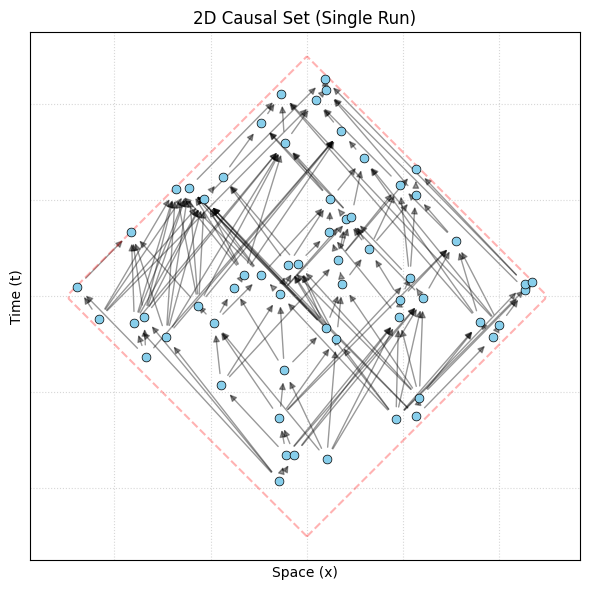

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from src.core_operations import sprinkle, causal_matrix
from src.visualization import plot_causet

try:
    from src import observables as obs
    HAS_OBS = True
except Exception as exc:
    HAS_OBS = False
    print("Observables import failed (likely missing scipy):", exc)

N = 60
dim = 2
points = sprinkle(N, dim=dim)
R = causal_matrix(points, dim=dim)

if HAS_OBS:
    r = obs.ordering_fraction(R)
    d_est = obs.estimate_dimension(r)
    L = obs.longest_chain_length(R)
    AC = obs.largest_antichain(R)
    print(f"Ordering fraction: {r:.3f}")
    if d_est is not None:
        print(f"Estimated dimension: {d_est:.2f}")
    print(f"Longest chain length: {L}")
    print(f"Largest antichain size: {AC}")
else:
    print("Skipping observables. Install scipy to enable dimension estimation.")

_ = plot_causet(points, R, dim=dim, title="2D Causal Set (Single Run)")

### How to Read the Results
- **Ordering fraction** is the density of causal relations. In 2D it clusters around a characteristic value.
- **Estimated dimension** inverts the Myrheim-Meyer relation; it should be close to 2 for a 2D sprinkle.
- **Longest chain** is the maximal timelike path length (a proxy for height).
- **Largest antichain** is the maximal set of unrelated points (a proxy for width).